In [93]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import quad
from numpy.polynomial.legendre import leggauss

### Part (a)

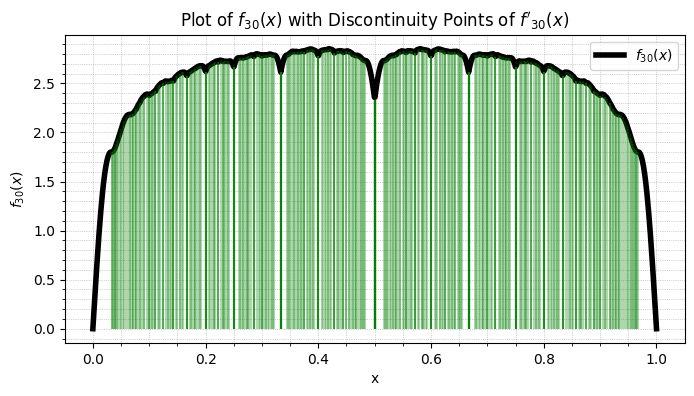

In [94]:
# Define the function fn(x)
def fn(x, n):
    result = 0
    for j in range(1, n + 1):
        result += np.abs(np.sin(j * np.pi * x))/j
    return result


# Define the number of terms
n = 30

# Generate x values
x = np.linspace(0, 1, 1000, endpoint=True)

# Calculate fn(x)
y = fn(x, n)

# Plot fn(x)
plt.figure(figsize=(8, 4))
plt.plot(x, y, label='$f_{30}(x)$', lw=4, color='black')

# Plot vertical lines at discontinuity points
for j in range(1, n+1):
    discontinuity_points = np.arange(0, 1, 1/j)
    plt.vlines(discontinuity_points, 0, fn(discontinuity_points, n), colors='green', alpha=.3)

plt.title('Plot of $f_{30}(x)$ with Discontinuity Points of $f\'_{30}(x)$')
plt.xlabel('x')
plt.ylabel('$f_{30}(x)$')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.show()


### Part (b)

In [95]:
def trapezoidal_rule(f, a, b, n):
    '''-----------------------------------------
    Function to impolement the trapezoidal rule
    
    Parameters:
        f - function to be integrated
        a - lower limit of integral
        b - lower limit of integral
        n - number of subintervals.
    
    Return:
        - Result of integration.
    --------------------------------------------'''
    
    # step size
    h = (b - a) / n
    
    # value of function at end points
    integral = 0.5 * (f(a) + f(b))
    
    # perform trapezoidal integration at internal points
    for i in range(1, n):
        integral += f(a + i * h)
    
    integral = h * integral
    return integral

In [96]:
# Define the limits of integration
a = 0
b = 1

# Set the number of subintervals
n = 50  

# Approximate the integral
approx_integral = trapezoidal_rule(lambda x: fn(x, 30), a, b, n)

# Approximation of integral using quad
approx_integral_quad, e = quad(lambda x: fn(x, 30), a, b)

print("Approximated integral using Trapezoidal Rule:", approx_integral)
print("Approximated integral using quad: ", approx_integral_quad)
print("Error using quad: ", e)

Approximated integral using Trapezoidal Rule: 2.5308975159364078
Approximated integral using quad:  2.543363181357029
Error using quad:  0.0008220285960751639


/tmp/ipykernel_1710748/2683129151.py:12: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  approx_integral_quad, e = quad(lambda x: fn(x, 30), a, b)


In [97]:
# Gaussian quadrature function
def gaussian_quadrature(f, a, b, n_points):
    
    # Get the Gaussian quadrature nodes and weights
    nodes, weights = leggauss(n_points)
    
    # Transform nodes and weights 
    transformed_nodes = 0.5 * (nodes + 1) * (b - a) + a
    transformed_weights = 0.5 * (b - a) * weights
    return np.sum(transformed_weights * f(transformed_nodes))

# Limits of integration
a = 0
b = 1

# Number of points for Gaussian quadrature
n_points = 50

# Approximation of integral using Gaussian quadrature
approx_integral_gaussian = gaussian_quadrature(lambda x: fn(x, 30), a, b, n_points)
print("Approximated integral using Gaussian quadrature: ", approx_integral_gaussian)

Approximated integral using Gaussian quadrature:  2.542204387079397


### Part (c)

In [99]:
sum = 0.0
for i in range(1, 31):
    sum += 2.0 / (i * np.pi)

print("Sum of the series:", sum)


Sum of the series: 2.5432877978979564
